# GSA300 - Geological Mapping via convolutional neural network in vegetated covered areas

In [1]:
import pandas as pd
import verde as vd
from sqlalchemy import create_engine

# Exemplo de engine (ajuste credenciais se necessário)
pg_user = "postgres"
pg_pass = "postgres"
pg_host = "localhost"
pg_port = "5432"
pg_db   = "geologia"

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
)

# 1) Query: pegar XY projetado + variáveis aerogeofísicas corrigidas
sql = """
SELECT
    x::double precision,
    y::double precision,
    ctcor_np,
    kperc_np,
    eu_np,
    eth_np,
    mdt,
    uth_razao,
    uk_razao,
    thk_razao
FROM geof.v_gamma_1082_sb21_za_ii1_ne;
"""

df = pd.read_sql_query(sql, engine)

# Garantir tipos numéricos
num_cols = [
    "x", "y", "mdt",
    "ctcor_np", "kperc_np", "eu_np", "eth_np",
    "uth_razao", "uk_razao", "thk_razao",
]
df[num_cols] = df[num_cols].astype("float64")

print(df.shape, df.columns)
sql_region = """
WITH folha AS (
    SELECT
        ST_Transform(geom, epsg) AS geom_proj
    FROM carto.folhas_cartograficas
    WHERE codigo = 'SB21_ZA_II1_NE'
)
SELECT
    ST_XMin(f.geom_proj) AS xmin,
    ST_XMax(f.geom_proj) AS xmax,
    ST_YMin(f.geom_proj) AS ymin,
    ST_YMax(f.geom_proj) AS ymax
FROM folha AS f;
"""

df_region = pd.read_sql_query(sql_region, engine)

xmin = df_region.loc[0, "xmin"]
xmax = df_region.loc[0, "xmax"]
ymin = df_region.loc[0, "ymin"]
ymax = df_region.loc[0, "ymax"]

region_xy = (xmin, xmax, ymin, ymax)
print("region_xy (folha):", region_xy)


(4993, 10) Index(['x', 'y', 'ctcor_np', 'kperc_np', 'eu_np', 'eth_np', 'mdt', 'uth_razao',
       'uk_razao', 'thk_razao'],
      dtype='object')
region_xy (folha): (np.float64(569153.8269262968), np.float64(583004.4102334864), np.float64(9322919.675001098), np.float64(9336755.996760607))


Interpolando ctcor_np...
ctcor_np: N_orig = 4993, N_block = 784


/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Interpolando kperc_np...
kperc_np: N_orig = 4993, N_block = 784


/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Interpolando eu_np...
eu_np: N_orig = 4993, N_block = 784


...

/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Interpolando uk_razao...
uk_razao: N_orig = 4993, N_block = 784


/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Interpolando thk_razao...
thk_razao: N_orig = 4993, N_block = 784


/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7518591aa160> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


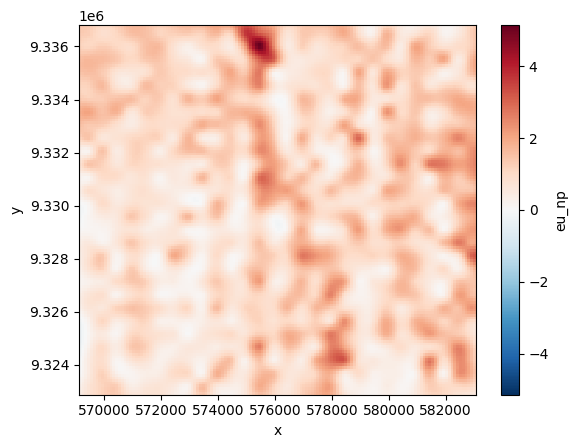

In [15]:
import numpy as np
import verde as vd

def interp_var_spline(
    df,
    var,
    region,
    spacing_block=500.0,
    spacing_grid=500/5,
    maxdist_mask=None,
):
    """
    Interpola 'var' de df(x,y,var) para um grid regular com Spline Verde.
    Fluxo:
        1) filtra NaN
        2) BlockReduce (median) com spacing_block (ex.: 492 m)
        3) Spline nos pontos reduzidos
        4) grid regular com spacing_grid (ex.: 100 m)
        5) opcional: distance_mask para limitar extrapolação

    Retorna: xarray.Dataset com coordenadas (y,x) e campo 'var'.
    """

    # 1) Dados válidos
    mask_valid = df[var].notna()
    x = df.loc[mask_valid, "x"].values
    y = df.loc[mask_valid, "y"].values
    z = df.loc[mask_valid, var].values

    coords = (x, y)

    # 2) BlockReduce para reduzir clustering (mediana por bloco de 492 m)
    reducer = vd.BlockReduce(
        reduction=np.median,
        spacing=spacing_block,
    )
    coords_red, z_red = reducer.filter(coords, z)

    # (opcional, só para conferência)
    print(f"{var}: N_orig = {z.size}, N_block = {z_red.size}")

    # 3) Ajuste do Spline com os pontos reduzidos
    spline = vd.Spline()
    spline.fit(coords_red, z_red)

    # 4) Grid regular (100 m por padrão)
    grid = spline.grid(
        region=region,
        spacing=spacing_grid,
        dims=("y", "x"),
        data_names=var,
    )

    # 5) Máscara de distância para limitar extrapolação
    if maxdist_mask is not None:
        grid = vd.distance_mask(
            coords_red,          # data_coordinates depois do BlockReduce
            maxdist=maxdist_mask,
            grid=grid,           # aplica máscara no Dataset
        )

    return grid

vars_interp = [
    "ctcor_np", "kperc_np", "eu_np", "eth_np",
    "mdt", "uth_razao", "uk_razao", "thk_razao",
]

spacing_block  = 490.0   # BlockReduce
spacing_grid   = spacing_block/5  # tamanho da célula do grid sintético
maxdist_mask   = 1000.0  # raio máximo de confiança (ajuste depois)
region_xy

grids = {}
for var in vars_interp:
    print(f"Interpolando {var}...")
    grids[var] = interp_var_spline(
        df,
        var,
        region=region_xy,
        spacing_grid=spacing_grid,
        spacing_block=spacing_block,
        maxdist_mask=maxdist_mask,
    )

first_var = vars_interp[0]
ds_grid = grids[first_var]
for var in vars_interp[1:]:
    ds_grid[var] = grids[var][var]

grid_df = vd.grid_to_table(ds_grid)
grid_df = grid_df.dropna(subset=[first_var])

var = 'eu_np'
grids[var][var].plot()


In [16]:
grid_df.describe(percentiles=(0.005,0.01,0.1,0.25,0.5,0.75,0.9,0.99,0.995)).T

,count,mean,std,min,0.5%,1%,10%,25%,50%,75%,90%,99%,99.5%,max
y,20164.0,9.329838e+06,4022.529720,9.322920e+06,9.322920e+06,9.323018e+06,9.324293e+06,9.326354e+06,9.329838e+06,9.333321e+06,9.335382e+06,9.336658e+06,9.336756e+06,9.336756e+06
x,20164.0,5.760791e+05,4026.675873,5.691538e+05,5.691538e+05,5.692521e+05,5.705291e+05,5.725919e+05,5.760791e+05,5.795663e+05,5.816292e+05,5.829062e+05,5.830044e+05,5.830044e+05
ctcor_np,20164.0,9.311196e+02,212.092020,4.016900e+02,5.361488e+02,5.523433e+02,6.689477e+02,7.714069e+02,9.011000e+02,1.080818e+03,1.236500e+03,1.441844e+03,1.489228e+03,1.678926e+03
kperc_np,20164.0,3.261209e-01,0.136341,1.498035e-02,6.329272e-02,8.140320e-02,1.738388e-01,2.322007e-01,3.106400e-01,3.962476e-01,4.936441e-01,7.729845e-01,8.621175e-01,1.089174e+00
eu_np,20164.0,1.049894e+00,0.590530,-2.729094e-01,7.624761e-03,6.235272e-02,3.502634e-01,6.197513e-01,9.889572e-01,1.400355e+00,1.796896e+00,2.703568e+00,3.137891e+00,5.145281e+00
eth_np,20164.0,1.231088e+01,3.489291,5.423772e+00,6.697406e+00,6.977297e+00,8.539405e+00,9.766866e+00,1.144892e+01,1.441371e+01,1.715138e+01,2.288914e+01,2.422037e+01,3.045327e+01
mdt,20164.0,1.569162e+02,21.803969,1.101682e+02,1.145722e+02,1.162511e+02,1.304069e+02,1.437963e+02,1.558062e+02,1.679367e+02,1.813625e+02,2.223440e+02,2.328811e+02,3.760614e+02
uth_razao,20164.0,8.792547e-02,0.043331,-1.501649e-02,-2.401516e-04,5.284484e-03,3.721277e-02,5.847559e-02,8.387141e-02,1.114966e-01,1.434520e-01,2.137539e-01,2.346317e-01,3.972085e-01
uk_razao,20164.0,3.609108e+00,2.242287,-7.844395e-01,-8.920042e-02,3.944132e-02,1.287312e+00,2.081947e+00,3.209680e+00,4.664185e+00,6.397821e+00,1.101922e+01,1.285899e+01,2.258439e+01
thk_razao,20164.0,4.494793e+01,23.880955,2.726812e-02,1.024668e+01,1.231921e+01,2.178354e+01,2.940837e+01,3.972616e+01,5.432816e+01,7.331203e+01,1.346256e+02,1.520852e+02,2.663354e+02


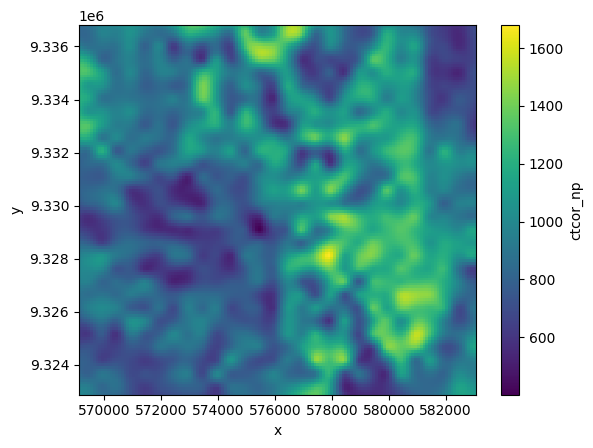

In [60]:
var = 'ctcor_np'
grids[var][var].plot()

## !pip install pystac-client planetary-computer shapely pyproj requests

In [27]:
#!/usr/bin/env python
"""
Baixa a melhor cena ASTER L1T de um STAC (Planetary Computer por padrão)
que cobre toda a área de uma região (AOI) e tem menos de 1% de nuvem.

Critérios:
- Coleção: aster-l1t
- Intersects: AOI (GeoJSON em WGS84)
- Cobertura geométrica: fração de área do AOI coberta >= min_coverage (padrão 0.99)
- Nuvem: properties["eo:cloud_cover"] < max_cloud_cover (padrão 1.0, i.e. < 1%)

Requer:
    pip install pystac-client planetary-computer shapely pyproj requests
"""

from pathlib import Path
from typing import Sequence, Optional, Tuple, List

import requests
from pystac_client import Client
import planetary_computer as pc
from shapely.geometry import shape, Polygon
from shapely.ops import transform
import pyproj


def build_local_equal_area_projector(aoi_geom: Polygon) -> pyproj.Transformer:
    """
    Cria um projetor LAEA local (equal-area) centrado no centróide do AOI,
    para que o cálculo de área (e fração de cobertura) seja metricamente consistente.
    """
    lon0, lat0 = aoi_geom.centroid.x, aoi_geom.centroid.y
    return pyproj.Transformer.from_crs(
        "EPSG:4326",
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} +datum=WGS84 +units=m +no_defs",
        always_xy=True,
    )


def coverage_fraction(aoi: Polygon, footprint: Polygon, transformer: pyproj.Transformer) -> float:
    """
    Retorna a fração de área do AOI coberta pela footprint da cena,
    usando projeção equal-area local.
    """
    project = transformer.transform
    aoi_p = transform(project, aoi)
    fp_p = transform(project, footprint)
    inter = aoi_p.intersection(fp_p)

    if aoi_p.is_empty or inter.is_empty:
        return 0.0

    return inter.area / aoi_p.area

def search_aster_items_filtered(
    aoi_geom_geojson: dict,
    datetime: str,
    stac_url: str = "https://planetarycomputer.microsoft.com/api/stac/v1",
    collection_id: str = "aster-l1t",
    min_coverage: float = 0.99,
    max_cloud_cover: float = 1.0,
    max_items: Optional[int] = 200,
):
    """
    Busca itens ASTER L1T em um STAC e retorna **lista de itens**
    que:
      - Intersectam o AOI,
      - Cobrem >= min_coverage da área do AOI,
      - Têm eo:cloud_cover < max_cloud_cover.

    A lista é ordenada por:
      1) menor nuvem
      2) maior cobertura
    """
    cat = Client.open(stac_url)
    aoi = shape(aoi_geom_geojson)

    search = cat.search(
        collections=[collection_id],
        intersects=aoi_geom_geojson,
        datetime=datetime,
        max_items=max_items,
    )
    items = list(search.get_items())
    if not items:
        raise RuntimeError("Nenhum item ASTER encontrado para este recorte/intervalo.")

    transformer = build_local_equal_area_projector(aoi)

    candidates: List[Tuple[float, float, object]] = []

    for item in items:
        footprint = shape(item.geometry)
        cov = coverage_fraction(aoi, footprint, transformer)

        cloud_raw = item.properties.get("eo:cloud_cover")
        if cloud_raw is None:
            continue
        try:
            cloud = float(cloud_raw)
        except Exception:
            continue

        if cov >= min_coverage and cloud < max_cloud_cover:
            candidates.append((cloud, cov, item))

    if not candidates:
        raise RuntimeError(
            "Nenhuma cena atende simultaneamente aos critérios: "
            f"cobertura >= {min_coverage*100:.1f}% e nuvem < {max_cloud_cover:.1f}%."
        )

    # Ordena por menor nuvem e, em seguida, maior cobertura
    candidates.sort(key=lambda t: (t[0], -t[1]))

    # Log rápido
    print("Cenas que passaram no filtro (ordenadas por nuvem, depois cobertura):")
    for cloud, cov, it in candidates:
        print(
            f"  id={it.id}, cloud={cloud:.2f}%, coverage={cov*100:.2f}%"
        )

    # Retorna apenas a lista de itens
    return [it for _, _, it in candidates]

def download_aster_assets(
    item,
    out_dir: str = "aster_download",
    assets: Sequence[str] = ("VNIR", "SWIR", "TIR"),
):
    """
    Faz o download dos assets especificados de um item ASTER L1T.

    Para Planetary Computer, os hrefs precisam ser assinados com planetary_computer.sign.
    """
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # Assina o item (Planetary Computer: gera URLs temporariamente acessíveis)
    signed_item = pc.sign(item)

    downloaded_files = []

    for asset_name in assets:
        if asset_name not in signed_item.assets:
            print(f"Aviso: asset '{asset_name}' não encontrado no item; ignorando.")
            continue

        asset = signed_item.assets[asset_name]
        url = asset.href

        # ASTER no PC é COG GeoTIFF, então usamos sempre .tif
        fname = out_path / f"{signed_item.id}_{asset_name}.tif"

        print(f"Baixando {asset_name} -> {fname}")
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            with open(fname, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    if chunk:
                        f.write(chunk)

        downloaded_files.append(str(fname))

    return downloaded_files

def main():
    # ------------------------------------------------------------
    # 1) Definição da região em coordenadas projetadas (region_xy)
    #    region_xy = (x_min, x_max, y_min, y_max)
    # ------------------------------------------------------------
    region_xy = (
        569153.8269262968,
        583004.4102334864,
        9322919.675001098,
        9336755.996760607,
    )
    x_min, x_max, y_min, y_max = region_xy

    poly_xy = Polygon(
        [
            (x_min, y_min),
            (x_max, y_min),
            (x_max, y_max),
            (x_min, y_max),
            (x_min, y_min),
        ]
    )

    # ------------------------------------------------------------
    # 2) Reprojeção para WGS84 (ajuste o CRS de origem!)
    #    Substitua "EPSG:XXXX" pelo SRID real da sua grade (UTM/SIRGAS etc.)
    # ------------------------------------------------------------
    CRS_ORIGEM = "EPSG:31981"  # ex: "EPSG:31981" (SIRGAS 2000 / UTM 21S) – CONFIRME

    transformer = Transformer.from_crs(
        CRS_ORIGEM,
        "EPSG:4326",
        always_xy=True,
    )

    poly_wgs84 = transform(transformer.transform, poly_xy)
    aoi_geom_geojson = mapping(poly_wgs84)

    # ------------------------------------------------------------
    # 3) Janela temporal das cenas ASTER
    # ------------------------------------------------------------
    datetime = "1900-01-01/2025-12-31"

    # 4) Buscar TODAS as cenas ASTER que cobrem o AOI e têm nuvem abaixo do limiar
    items = search_aster_items_filtered(
        aoi_geom_geojson=aoi_geom_geojson,
        datetime=datetime,
        min_coverage=0.99,   # >= 99% da área da região
        max_cloud_cover=50.0  # < 1% de nuvem; se quiser relaxar, aumente
    )

    print(f"\nTotal de cenas selecionadas: {len(items)}")

    # 5) Baixar assets de TODAS as cenas
    #    Se preferir separar por pasta, pode usar o id do item no nome
    for item in items:
        out_dir = f"aster_{item.id}"
        print(f"\nBaixando assets para item {item.id} em {out_dir} ...")
        files = download_aster_assets(
            item,
            out_dir=out_dir,
            assets=("VNIR", "SWIR"),
        )
        print("  Arquivos baixados:")
        for f in files:
            print("    ", f)

if __name__ == "__main__":
    main()

Cenas que passaram no filtro (ordenadas por nuvem, depois cobertura):
  id=AST_L1T_00310202005141145_20150511152438, cloud=11.00%, coverage=100.00%
  id=AST_L1T_00305132005141212_20150509113333, cloud=15.00%, coverage=100.00%
  id=AST_L1T_00306012006141203_20150514154927, cloud=42.00%, coverage=100.00%

Total de cenas selecionadas: 3

Baixando assets para item AST_L1T_00310202005141145_20150511152438 em aster_AST_L1T_00310202005141145_20150511152438 ...
Baixando VNIR -> aster_AST_L1T_00310202005141145_20150511152438/AST_L1T_00310202005141145_20150511152438_VNIR.tif
Baixando SWIR -> aster_AST_L1T_00310202005141145_20150511152438/AST_L1T_00310202005141145_20150511152438_SWIR.tif
  Arquivos baixados:
     aster_AST_L1T_00310202005141145_20150511152438/AST_L1T_00310202005141145_20150511152438_VNIR.tif
     aster_AST_L1T_00310202005141145_20150511152438/AST_L1T_00310202005141145_20150511152438_SWIR.tif

Baixando assets para item AST_L1T_00305132005141212_20150509113333 em aster_AST_L1T_0030

In [38]:
#!/usr/bin/env python
"""
Aquisição de imagens Sentinel-2 (L2A) no Microsoft Planetary Computer
para a data mais próxima de uma cena ASTER L1T já baixada.
"""

from __future__ import annotations

from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import Sequence, List

import requests
from pystac_client import Client
import planetary_computer as pc


# ----------------------------------------------------------------------
# Utilitários STAC / tempo
# ----------------------------------------------------------------------
def _item_datetime(item) -> datetime:
    if getattr(item, "datetime", None) is not None:
        dt = item.datetime
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt

    dt_str = item.properties["datetime"]
    if dt_str.endswith("Z"):
        dt_str = dt_str.replace("Z", "+00:00")
    dt = datetime.fromisoformat(dt_str)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt


def _to_iso_z(dt: datetime) -> str:
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")


# ----------------------------------------------------------------------
# ASTER: resolver ID do item a partir do arquivo local
# ----------------------------------------------------------------------
def resolve_aster_item_id_from_path(tif_path: Path) -> str:
    """
    <item_id>_VNIR.tif, <item_id>_SWIR.tif ou <item_id>_TIR.tif
    -> item_id
    """
    stem = tif_path.stem  # sem ".tif"
    for suffix in ("_VNIR", "_SWIR", "_TIR"):
        if stem.endswith(suffix):
            return stem[: -len(suffix)]
    return stem


def get_aster_item_from_pc(
    item_id: str,
    stac_url: str = "https://planetarycomputer.microsoft.com/api/stac/v1",
    collection_id: str = "aster-l1t",
):
    """
    Obtém o item ASTER L1T no Planetary Computer via /search,
    informando explicitamente a coleção (evita erro 'collection is required').
    """
    cat = Client.open(stac_url)

    search = cat.search(
        collections=[collection_id],
        ids=[item_id],
        max_items=1,
    )
    items = list(search.get_items())

    if not items:
        raise RuntimeError(
            f"Item ASTER '{item_id}' não encontrado na coleção '{collection_id}'."
        )

    if len(items) > 1:
        print(
            f"Aviso: mais de um item retornado para id='{item_id}' "
            f"na coleção '{collection_id}'. Usando o primeiro."
        )

    return items[0]


# ----------------------------------------------------------------------
# Sentinel-2: busca próxima à data do ASTER
# ----------------------------------------------------------------------
def search_sentinel2_near_aster(
    aster_item,
    aoi_geom_geojson: dict,
    days_window: int = 730,
    max_cloud_cover: float = 30.0,
    stac_url: str = "https://planetarycomputer.microsoft.com/api/stac/v1",
    collection_id: str = "sentinel-2-l2a",
    max_items: int = 200,
):
    cat = Client.open(stac_url)
    ref_dt = _item_datetime(aster_item)

    t_min = ref_dt - timedelta(days=days_window)
    t_max = ref_dt + timedelta(days=days_window)
    datetime_str = f"{_to_iso_z(t_min)}/{_to_iso_z(t_max)}"

    search = cat.search(
        collections=[collection_id],
        intersects=aoi_geom_geojson,
        datetime=datetime_str,
        max_items=max_items,
        query={"eo:cloud_cover": {"lt": max_cloud_cover}},
    )

    items = list(search.get_items())
    if not items:
        raise RuntimeError(
            "Nenhuma Sentinel-2 L2A encontrada para o AOI na janela temporal "
            f"±{days_window} dias com eo:cloud_cover < {max_cloud_cover}."
        )

    def sort_key(it):
        dt = _item_datetime(it)
        delta_sec = abs((dt - ref_dt).total_seconds())
        cloud_raw = it.properties.get("eo:cloud_cover", 9999.0)
        try:
            cloud = float(cloud_raw)
        except Exception:
            cloud = 9999.0
        return (delta_sec, cloud)

    items.sort(key=sort_key)

    print(
        f"Encontrados {len(items)} itens Sentinel-2 L2A no AOI, "
        f"janela ±{days_window} dias, eo:cloud_cover < {max_cloud_cover}."
    )
    print("Top 5 (mais próximos temporalmente):")
    for it in items[:5]:
        dt = _item_datetime(it)
        cloud = it.properties.get("eo:cloud_cover", None)
        print(f"  id={it.id}, datetime={dt.isoformat()}, eo:cloud_cover={cloud}")

    return items


# ----------------------------------------------------------------------
# Download de assets Sentinel-2
# ----------------------------------------------------------------------
def download_sentinel2_assets(
    item,
    out_dir: Path,
    assets: Sequence[str] = ("B02", "B03", "B04", "B08", "SCL"),
) -> List[str]:
    out_dir.mkdir(parents=True, exist_ok=True)

    signed_item = pc.sign(item)
    downloaded_files: List[str] = []

    for asset_name in assets:
        if asset_name not in signed_item.assets:
            print(f"Aviso: asset '{asset_name}' não encontrado no item {item.id}; ignorando.")
            continue

        asset = signed_item.assets[asset_name]
        url = asset.href
        fname = out_dir / f"{signed_item.id}_{asset_name}.tif"

        print(f"Baixando {asset_name} -> {fname}")
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            with open(fname, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    if chunk:
                        f.write(chunk)

        downloaded_files.append(str(fname))

    return downloaded_files


# ----------------------------------------------------------------------
# Função de alto nível para notebook
# ----------------------------------------------------------------------
def run_sentinel2_from_aster(
    aster_tif_path: str,
    days_window: int = 730,
    max_cloud: float = 30.0,
    top_n: int = 1,
    out_dir: str = "sentinel2_from_aster",
):
    tif_path = Path(aster_tif_path)
    if not tif_path.exists():
        raise FileNotFoundError(f"Arquivo ASTER não encontrado: {tif_path}")

    # 1) ID do item ASTER
    aster_item_id = resolve_aster_item_id_from_path(tif_path)
    print(f"Item ASTER inferido: {aster_item_id}")

    # 2) Obter item ASTER no STAC (usando search com collections+ids)
    aster_item = get_aster_item_from_pc(aster_item_id)
    aster_dt = _item_datetime(aster_item)
    print(f"Data/hora ASTER (UTC): {aster_dt.isoformat()}")

    # 3) AOI = geometria da cena ASTER
    aoi_geom_geojson = aster_item.geometry

    # 4) Buscar cenas Sentinel-2
    s2_items = search_sentinel2_near_aster(
        aster_item=aster_item,
        aoi_geom_geojson=aoi_geom_geojson,
        days_window=days_window,
        max_cloud_cover=max_cloud,
    )

    top_n = max(1, min(top_n, len(s2_items)))
    print(f"\nBaixando as {top_n} primeiras cenas Sentinel-2 (mais próximas temporalmente)...")

    base_out = Path(out_dir)
    all_downloaded: List[str] = []

    for i, s2_item in enumerate(s2_items[:top_n], start=1):
        s2_dt = _item_datetime(s2_item)
        cloud = s2_item.properties.get("eo:cloud_cover", None)
        print(
            f"\n[{i}/{top_n}] Sentinel-2 id={s2_item.id}, "
            f"datetime={s2_dt.isoformat()}, eo:cloud_cover={cloud}"
        )

        s2_out_dir = base_out / s2_item.id
        files = download_sentinel2_assets(
            s2_item,
            out_dir=s2_out_dir,
            assets=("B02", "B03", "B04", "B08", "SCL"),
        )

        print("  Arquivos baixados:")
        for f in files:
            print("    ", f)
        all_downloaded.extend(files)

    return all_downloaded


In [43]:
aster_tif = "/home/ggrl/projetos/PreditorTerra/aster_best_scene/AST_L1T_00310202005141145_20150511152438_SWIR.tif"

arquivos = run_sentinel2_from_aster(
    aster_tif_path=aster_tif,
    days_window=25000,
    max_cloud=40.0,
    top_n=5,
    out_dir="sentinel2_from_aster"
)


Item ASTER inferido: AST_L1T_00310202005141145_20150511152438
Data/hora ASTER (UTC): 2005-10-20T14:11:45.205000+00:00
Encontrados 200 itens Sentinel-2 L2A no AOI, janela ±25000 dias, eo:cloud_cover < 50.0.
Top 5 (mais próximos temporalmente):
  id=S2A_MSIL2A_20230728T140711_R110_T21MXP_20241020T073225, datetime=2023-07-28T14:07:11.024000+00:00, eo:cloud_cover=0.000506
  id=S2A_MSIL2A_20230728T140711_R110_T21MXP_20230728T233257, datetime=2023-07-28T14:07:11.024000+00:00, eo:cloud_cover=0.000531
  id=S2B_MSIL2A_20230802T140709_R110_T21MWP_20241014T191502, datetime=2023-08-02T14:07:09.024000+00:00, eo:cloud_cover=15.934044
  id=S2B_MSIL2A_20230802T140709_R110_T21MWP_20230802T194446, datetime=2023-08-02T14:07:09.024000+00:00, eo:cloud_cover=20.511557
  id=S2B_MSIL2A_20230802T140709_R110_T21MXP_20241014T191502, datetime=2023-08-02T14:07:09.024000+00:00, eo:cloud_cover=46.581766

Baixando as 5 primeiras cenas Sentinel-2 (mais próximas temporalmente)...

[1/5] Sentinel-2 id=S2A_MSIL2A_2023072

In [44]:
#!/usr/bin/env python
"""
Busca e download de imagens Sentinel-2 L2A no Microsoft Planetary Computer
para a data mais próxima de uma cena ASTER L1T, usando como área de busca
a geometria de uma folha cartográfica (ex.: SB21_ZA_II2_NE).

Fluxo:

1) Lê do PostGIS a geometria da folha (tabela carto.folhas_cartograficas),
   transforma para WGS84 (EPSG:4326) e converte para GeoJSON Geometry.

2) A partir do arquivo local ASTER (VNIR/SWIR/TIR .tif), infere o ID do item
   ASTER no STAC (removendo o sufixo _VNIR/_SWIR/_TIR) e obtém o item via
   /search (coleção aster-l1t).

3) Usa a data/hora do ASTER como referência temporal e procura itens
   Sentinel-2 L2A que:
   - intersectam a folha (AOI da folha);
   - estão dentro de uma janela temporal ±days_window dias;
   - têm eo:cloud_cover < max_cloud.

4) Ordena as Sentinel-2 por |t_S2 - t_ASTER| e, em seguida, por nuvem,
   e baixa os assets desejados (por padrão: B02, B03, B04, B08, SCL).

Dependências:

    pip install pystac-client planetary-computer requests sqlalchemy psycopg2-binary pandas
"""

from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import Sequence, List

import requests
import pandas as pd
from sqlalchemy import create_engine
from pystac_client import Client
import planetary_computer as pc


# ----------------------------------------------------------------------
# Configuração do Postgres (ajuste conforme seu ambiente)
# ----------------------------------------------------------------------
PG_USER = "postgres"
PG_PASS = "postgres"
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB   = "geologia"

PG_CONN_STR = f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"


# ----------------------------------------------------------------------
# Utilitários STAC / tempo
# ----------------------------------------------------------------------
def _item_datetime(item) -> datetime:
    """
    Retorna datetime (UTC) de um item STAC (pystac.Item),
    usando item.datetime ou properties['datetime'].
    """
    if getattr(item, "datetime", None) is not None:
        dt = item.datetime
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt

    dt_str = item.properties["datetime"]
    if dt_str.endswith("Z"):
        dt_str = dt_str.replace("Z", "+00:00")
    dt = datetime.fromisoformat(dt_str)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt


def _to_iso_z(dt: datetime) -> str:
    """
    Converte datetime timezone-aware para string ISO 8601 terminada em 'Z'.
    """
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")


# ----------------------------------------------------------------------
# Geometria da folha (PostGIS -> GeoJSON WGS84)
# ----------------------------------------------------------------------
def get_folha_geom_geojson(
    codigo_folha: str,
    conn_str: str = PG_CONN_STR,
    target_srid: int = 4326,
) -> dict:
    """
    Busca no PostGIS a geometria da folha (carto.folhas_cartograficas),
    transforma para target_srid (default: 4326) e retorna como GeoJSON Geometry.

    Requer que a tabela carto.folhas_cartograficas tenha pelo menos:
      - codigo (varchar)
      - geom (geometry)
    """
    engine = create_engine(conn_str)

    sql = f"""
    SELECT
        ST_AsGeoJSON(ST_Transform(geom, {target_srid})) AS geom_geojson
    FROM carto.folhas_cartograficas
    WHERE codigo = %(codigo)s
    LIMIT 1;
    """

    df = pd.read_sql(sql, engine, params={"codigo": codigo_folha})

    if df.empty or df.loc[0, "geom_geojson"] is None:
        raise RuntimeError(
            f"Não foi encontrada geometria para a folha '{codigo_folha}' "
            "em carto.folhas_cartograficas."
        )

    return json.loads(df.loc[0, "geom_geojson"])


# ----------------------------------------------------------------------
# ASTER: resolver ID do item a partir do arquivo local
# ----------------------------------------------------------------------
def resolve_aster_item_id_from_path(tif_path: Path) -> str:
    """
    Infere o ID do item ASTER a partir do nome do arquivo GeoTIFF local:

       <item_id>_VNIR.tif
       <item_id>_SWIR.tif
       <item_id>_TIR.tif

    Exemplo:
       AST_L1T_00310202005141145_20150511152438_SWIR.tif
       -> AST_L1T_00310202005141145_20150511152438
    """
    stem = tif_path.stem  # sem ".tif"
    for suffix in ("_VNIR", "_SWIR", "_TIR"):
        if stem.endswith(suffix):
            return stem[: -len(suffix)]
    return stem


def get_aster_item_from_pc(
    item_id: str,
    stac_url: str = "https://planetarycomputer.microsoft.com/api/stac/v1",
    collection_id: str = "aster-l1t",
):
    """
    Obtém o item ASTER L1T no Planetary Computer via /search,
    informando explicitamente a coleção (collection é obrigatório).
    """
    cat = Client.open(stac_url)

    search = cat.search(
        collections=[collection_id],
        ids=[item_id],
        max_items=1,
    )
    items = list(search.get_items())

    if not items:
        raise RuntimeError(
            f"Item ASTER '{item_id}' não encontrado na coleção '{collection_id}'."
        )

    if len(items) > 1:
        print(
            f"Aviso: mais de um item retornado para id='{item_id}' "
            f"na coleção '{collection_id}'. Usando o primeiro."
        )

    return items[0]


# ----------------------------------------------------------------------
# Sentinel-2: busca próxima à data do ASTER, usando AOI da folha
# ----------------------------------------------------------------------
def search_sentinel2_near_aster(
    aster_item,
    aoi_geom_geojson: dict,
    days_window: int = 730,
    max_cloud_cover: float = 30.0,
    stac_url: str = "https://planetarycomputer.microsoft.com/api/stac/v1",
    collection_id: str = "sentinel-2-l2a",
    max_items: int = 200,
):
    """
    Busca imagens Sentinel-2 L2A próximas (no tempo) de um item ASTER,
    mas usando como área de busca o AOI da folha (aoi_geom_geojson).

    Critérios:
      - Coleção: sentinel-2-l2a
      - intersects: aoi_geom_geojson (folha, em WGS84)
      - datetime: [t_aster - days_window, t_aster + days_window]
      - eo:cloud_cover < max_cloud_cover

    Ordenação dos resultados:
      1) |t_s2 - t_aster|
      2) eo:cloud_cover

    Retorna lista de pystac.Item (ordenada).
    """
    cat = Client.open(stac_url)
    ref_dt = _item_datetime(aster_item)

    t_min = ref_dt - timedelta(days=days_window)
    t_max = ref_dt + timedelta(days=days_window)
    datetime_str = f"{_to_iso_z(t_min)}/{_to_iso_z(t_max)}"

    search = cat.search(
        collections=[collection_id],
        intersects=aoi_geom_geojson,
        datetime=datetime_str,
        max_items=max_items,
        query={"eo:cloud_cover": {"lt": max_cloud_cover}},
    )

    items = list(search.get_items())
    if not items:
        raise RuntimeError(
            "Nenhuma Sentinel-2 L2A encontrada para a folha na janela temporal "
            f"±{days_window} dias com eo:cloud_cover < {max_cloud_cover}."
        )

    def sort_key(it):
        dt = _item_datetime(it)
        delta_sec = abs((dt - ref_dt).total_seconds())
        cloud_raw = it.properties.get("eo:cloud_cover", 9999.0)
        try:
            cloud = float(cloud_raw)
        except Exception:
            cloud = 9999.0
        return (delta_sec, cloud)

    items.sort(key=sort_key)

    print(
        f"Encontrados {len(items)} itens Sentinel-2 L2A intersectando a folha, "
        f"janela ±{days_window} dias, eo:cloud_cover < {max_cloud_cover}."
    )
    print("Top 5 (mais próximos temporalmente):")
    for it in items[:5]:
        dt = _item_datetime(it)
        cloud = it.properties.get("eo:cloud_cover", None)
        print(f"  id={it.id}, datetime={dt.isoformat()}, eo:cloud_cover={cloud}")

    return items


# ----------------------------------------------------------------------
# Download de assets Sentinel-2
# ----------------------------------------------------------------------
def download_sentinel2_assets(
    item,
    out_dir: Path,
    assets: Sequence[str] = ("B02", "B03", "B04", "B08", "SCL"),
) -> List[str]:
    """
    Faz download dos assets Sentinel-2 L2A de um item STAC para out_dir.
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    signed_item = pc.sign(item)
    downloaded_files: List[str] = []

    for asset_name in assets:
        if asset_name not in signed_item.assets:
            print(f"Aviso: asset '{asset_name}' não encontrado no item {item.id}; ignorando.")
            continue

        asset = signed_item.assets[asset_name]
        url = asset.href
        fname = out_dir / f"{signed_item.id}_{asset_name}.tif"

        print(f"Baixando {asset_name} -> {fname}")
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            with open(fname, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    if chunk:
                        f.write(chunk)

        downloaded_files.append(str(fname))

    return downloaded_files


# ----------------------------------------------------------------------
# Função de alto nível: ASTER + folha -> Sentinel-2
# ----------------------------------------------------------------------
def run_sentinel2_from_aster_folha(
    aster_tif_path: str,
    codigo_folha: str = "SB21_ZA_II2_NE",
    days_window: int = 730,
    max_cloud: float = 30.0,
    top_n: int = 1,
    out_dir: str = "sentinel2_from_aster_folha",
):
    """
    Fluxo completo:

    - Lê a geometria da folha (codigo_folha) em WGS84 (GeoJSON).
    - Infere o item_id ASTER a partir do nome do arquivo .tif.
    - Obtém o item ASTER no Planetary Computer (coleção aster-l1t).
    - Usa a data do ASTER como referência temporal.
    - Busca Sentinel-2 L2A que intersectam a folha e estão próximas no tempo.
    - Baixa os assets Sentinel-2 das top_n cenas mais próximas.

    Parameters
    ----------
    aster_tif_path : str
        Caminho para o arquivo ASTER GeoTIFF (VNIR/SWIR/TIR).
    codigo_folha : str
        Código da folha cartográfica (ex.: 'SB21_ZA_II2_NE').
    days_window : int
        Janela temporal ± (dias) em torno da data do ASTER.
    max_cloud : float
        Limite de eo:cloud_cover (%) para Sentinel-2.
    top_n : int
        Número de cenas Sentinel-2 a baixar (ordenadas por proximidade temporal).
    out_dir : str
        Diretório base para salvar as cenas Sentinel-2.
    """
    tif_path = Path(aster_tif_path)
    if not tif_path.exists():
        raise FileNotFoundError(f"Arquivo ASTER não encontrado: {tif_path}")

    # 1) Geometria da folha em WGS84
    print(f"Buscando geometria da folha '{codigo_folha}' no PostGIS...")
    aoi_geom_geojson = get_folha_geom_geojson(codigo_folha)
    print("Geometria da folha obtida com sucesso.")

    # 2) ID do item ASTER
    aster_item_id = resolve_aster_item_id_from_path(tif_path)
    print(f"Item ASTER inferido a partir do arquivo: {aster_item_id}")

    # 3) Obter item ASTER no STAC
    aster_item = get_aster_item_from_pc(aster_item_id)
    aster_dt = _item_datetime(aster_item)
    print(f"Data/hora ASTER (UTC): {aster_dt.isoformat()}")

    # 4) Buscar Sentinel-2 L2A usando AOI da folha
    s2_items = search_sentinel2_near_aster(
        aster_item=aster_item,
        aoi_geom_geojson=aoi_geom_geojson,
        days_window=days_window,
        max_cloud_cover=max_cloud,
    )

    top_n = max(1, min(top_n, len(s2_items)))
    print(f"\nBaixando as {top_n} primeiras cenas Sentinel-2 (mais próximas temporalmente)...")

    base_out = Path(out_dir)
    all_downloaded: List[str] = []

    for i, s2_item in enumerate(s2_items[:top_n], start=1):
        s2_dt = _item_datetime(s2_item)
        cloud = s2_item.properties.get("eo:cloud_cover", None)
        print(
            f"\n[{i}/{top_n}] Sentinel-2 id={s2_item.id}, "
            f"datetime={s2_dt.isoformat()}, eo:cloud_cover={cloud}"
        )

        s2_out_dir = base_out / f"{codigo_folha}_{s2_item.id}"
        files = download_sentinel2_assets(
            s2_item,
            out_dir=s2_out_dir,
            assets=("B02",
                   # "B03", "B04", "B08", "SCL"
                   ),  # ajuste se quiser outras bandas
        )

        print("  Arquivos baixados:")
        for f in files:
            print("    ", f)
        all_downloaded.extend(files)

    return all_downloaded


In [52]:
import requests
from pathlib import Path
import planetary_computer as pc

def download_sentinel2_assets(
    item,
    out_dir: Path,
    assets=("B02", "B03", "B04", "B08", "SCL"),
):
    out_dir.mkdir(parents=True, exist_ok=True)
    signed_item = pc.sign(item)
    files = []

    for asset_name in assets:
        if asset_name not in signed_item.assets:
            print(f"Aviso: asset '{asset_name}' não está disponível em {item.id}")
            continue

        href = signed_item.assets[asset_name].href
        out_file = out_dir / f"{signed_item.id}_{asset_name}.tif"
        print(f"Baixando {asset_name} -> {out_file}")

        with requests.get(href, stream=True) as r:
            r.raise_for_status()
            with open(out_file, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    if chunk:
                        f.write(chunk)
        files.append(str(out_file))

    return files


In [54]:

# 'candidates' e 'best' vieram de search_items_for_folha(...)
best_item = best["item"]

arquivos = download_sentinel2_assets(
    best_item,
    out_dir=Path("sentinel2_SB21_ZA_II1_NE_best"),
    assets=(
        "B02", "B03", "B04",   # B, G, R
        "B05", "B06", "B07",   # Vegetation RedEdge 1, 2 e 3
        "B08", "B11", "B12",   # NIR, SWIR-1, SWIR-2      
        "B8A", "SCL"),
)

arquivos


Baixando B02 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B02.tif
Baixando B03 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B03.tif
Baixando B04 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B04.tif
Baixando B05 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B05.tif
Baixando B06 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B06.tif
Baixando B07 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B07.tif
Baixando B08 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B08.tif
Baixando B11 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B11.tif
Baixando B12 -> sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B12.tif
Baixando B8A -> sen

['sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B02.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B03.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B04.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B05.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B06.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B07.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B08.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B11.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B12.tif',
 'sentinel2_SB21_ZA_II1_NE_best/S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220_B8A.tif',
 'sentinel2_SB21_ZA_II1_NE_bes

In [56]:
#!/usr/bin/env python
"""
Seleção de cena ASTER L1T no Planetary Computer para uma folha cartográfica:

Critérios:
- coleção: aster-l1t
- AOI: geom da folha (carto.folhas_cartograficas, EPSG:4326)
- fração de cobertura da folha ≥ min_coverage (ex.: 0.9 = 90%)
- nuvem < max_cloud (%) via metadado (eo:cloud_cover)
- cena com |data_item − data_alvo| mínima; em empate, menor nuvem e maior cobertura

Saída:
- lista de candidatos (ordenados)
- melhor cena (primeiro candidato)
"""

from __future__ import annotations

import json
from datetime import datetime, timezone
from typing import Dict, Any, List, Optional, Tuple

import pandas as pd
from sqlalchemy import create_engine
from shapely.geometry import shape
from shapely.ops import transform as shp_transform
from pyproj import Transformer
from pystac_client import Client
import planetary_computer as pc


# ----------------------------------------------------------------------
# Configuração PostGIS (ajuste para o seu ambiente)
# ----------------------------------------------------------------------
PG_USER = "postgres"
PG_PASS = "postgres"
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB   = "geologia"

PG_CONN_STR = (
    f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)


# ----------------------------------------------------------------------
# Utilitários de data/hora
# ----------------------------------------------------------------------
def parse_target_date(date_str: str) -> datetime:
    """Converte 'YYYY-MM-DD' em datetime UTC (meia-noite)."""
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    return dt.replace(tzinfo=timezone.utc)


def item_datetime(item) -> datetime:
    """Retorna datetime timezone-aware (UTC) de um pystac.Item."""
    if getattr(item, "datetime", None) is not None:
        dt = item.datetime
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt

    dt_str = item.properties["datetime"]
    if dt_str.endswith("Z"):
        dt_str = dt_str.replace("Z", "+00:00")
    dt = datetime.fromisoformat(dt_str)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt


# ----------------------------------------------------------------------
# Geometria da folha (PostGIS → GeoJSON WGS84)
# ----------------------------------------------------------------------
def get_folha_geom_geojson(
    codigo_folha: str,
    conn_str: str = PG_CONN_STR,
    target_srid: int = 4326,
) -> Dict[str, Any]:
    """
    Lê a geometria da folha em carto.folhas_cartograficas e devolve GeoJSON
    em EPSG:4326.

    Supõe:
      - coluna 'codigo' (varchar)
      - coluna 'geom' (geometry)
    """
    engine = create_engine(conn_str)

    sql = f"""
    SELECT
        ST_AsGeoJSON(ST_Transform(geom, {target_srid})) AS geom_geojson
    FROM carto.folhas_cartograficas
    WHERE codigo = %(codigo)s
    LIMIT 1;
    """

    df = pd.read_sql(sql, engine, params={"codigo": codigo_folha})

    if df.empty or df.loc[0, "geom_geojson"] is None:
        raise RuntimeError(
            f"Não foi encontrada geometria para a folha '{codigo_folha}' "
            "em carto.folhas_cartograficas."
        )

    return json.loads(df.loc[0, "geom_geojson"])


# ----------------------------------------------------------------------
# Projeção equal-area local e cobertura
# ----------------------------------------------------------------------
def build_local_equal_area_transformer(
    geom_geojson: Dict[str, Any]
) -> Transformer:
    """
    Projeção LAEA (equal-area) centrada no centróide da geometria (WGS84).
    """
    geom = shape(geom_geojson)
    lon0, lat0 = geom.centroid.x, geom.centroid.y

    laea_proj = (
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} "
        "+datum=WGS84 +units=m +no_defs"
    )
    transformer = Transformer.from_crs(
        "EPSG:4326",
        laea_proj,
        always_xy=True,
    )
    return transformer


def coverage_fraction(
    folha_geom_geojson: Dict[str, Any],
    item_geom_geojson: Dict[str, Any],
    transformer: Transformer,
) -> float:
    """
    Fração de cobertura da folha pela footprint do item:

        frac = área( folha ∩ item ) / área( folha )

    calculada em projeção equal-area local.
    """
    folha_geom = shape(folha_geom_geojson)
    item_geom = shape(item_geom_geojson)

    project = transformer.transform
    folha_proj = shp_transform(project, folha_geom)
    item_proj = shp_transform(project, item_geom)

    inter = folha_proj.intersection(item_proj)

    if folha_proj.is_empty or inter.is_empty:
        return 0.0

    return inter.area / folha_proj.area


# ----------------------------------------------------------------------
# Cloud cover via metadado STAC
# ----------------------------------------------------------------------
def get_cloud_cover(item) -> Optional[float]:
    """
    Retorna porcentagem de nuvem.

    Para ASTER L1T no Planetary Computer, usa:
      - properties['eo:cloud_cover']
    """
    props = item.properties or {}
    if "eo:cloud_cover" in props and props["eo:cloud_cover"] is not None:
        try:
            return float(props["eo:cloud_cover"])
        except Exception:
            return None
    return None


# ----------------------------------------------------------------------
# Busca de itens ASTER para uma folha, com ranking por data e nuvem
# ----------------------------------------------------------------------
def search_aster_for_folha(
    codigo_folha: str,
    target_date_str: str,
    collection_id: str = "aster-l1t",
    stac_url: str = "https://planetarycomputer.microsoft.com/api/stac/v1",
    # intervalo amplo que inclui 2008; ajuste se quiser restringir
    search_datetime: str = "2000-01-01/2015-12-31",
    min_coverage: float = 0.90,
    max_cloud: float = 1.0,
    max_items: int = 2000,
) -> Tuple[List[Dict[str, Any]], Optional[Dict[str, Any]]]:
    """
    Seleciona cenas ASTER L1T para uma folha cartográfica.

    Parâmetros principais:
      codigo_folha    : código da folha (ex.: 'SB21_ZA_II1_NE')
      target_date_str : data-alvo 'YYYY-MM-DD' (ex.: '2008-07-15')
      collection_id   : coleção STAC (default 'aster-l1t')
      stac_url        : endpoint STAC (Planetary Computer)
      search_datetime : intervalo de busca STAC (string ISO)
      min_coverage    : fração mínima de cobertura da folha (0.9 = 90%)
      max_cloud       : nuvem máxima (%) (ex.: 1.0)
      max_items       : limite de itens retornados pelo STAC

    Critérios aplicados:
      1) intersects = geom da folha (WGS84)
      2) datetime ∈ search_datetime
      3) cobertura_folha ≥ min_coverage
      4) cloud_cover < max_cloud
      5) ordenação por (|data_item − data_alvo|, cloud_cover, -coverage)

    Retorno:
      (candidates, best)
        candidates: lista de dicts com campos:
            - id
            - datetime
            - delta_days
            - coverage_fraction
            - coverage_percent
            - cloud_cover
        best     : dict do melhor item ou None
    """
    # 1) Geometria da folha
    folha_geom_geojson = get_folha_geom_geojson(codigo_folha)
    folha_shape = shape(folha_geom_geojson)
    print(
        f"Folha '{codigo_folha}' carregada. "
        f"Área WGS84 (aprox): {folha_shape.area:.6f} (graus²)"
    )

    transformer = build_local_equal_area_transformer(folha_geom_geojson)

    # 2) Catálogo STAC
    cat = Client.open(stac_url)

    # 3) Busca ASTER
    print(
        f"Buscando itens na coleção '{collection_id}' que intersectem a folha..."
    )
    search = cat.search(
        collections=[collection_id],
        intersects=folha_geom_geojson,
        datetime=search_datetime,
        max_items=max_items,
    )
    items = list(search.get_items())
    print(
        f"Total de itens ASTER retornados pelo STAC "
        f"(antes de filtros locais): {len(items)}"
    )

    if not items:
        return [], None

    target_date = parse_target_date(target_date_str).date()

    candidates: List[Dict[str, Any]] = []

    for item in items:
        # data/hora do item
        dt = item_datetime(item)
        dt_date = dt.date()
        delta_days = abs((dt_date - target_date).days)

        # nuvem
        cloud = get_cloud_cover(item)
        if cloud is None:
            # se quiser aceitar itens sem nuvem, remova este continue
            continue
        if cloud >= max_cloud:
            continue

        # fração de cobertura
        frac = coverage_fraction(
            folha_geom_geojson=folha_geom_geojson,
            item_geom_geojson=item.geometry,
            transformer=transformer,
        )
        if frac < min_coverage:
            continue

        candidates.append(
            {
                "id": item.id,
                "datetime": dt.isoformat(),
                "delta_days": delta_days,
                "coverage_fraction": frac,
                "coverage_percent": frac * 100.0,
                "cloud_cover": cloud,
                "item": item,
            }
        )

    if not candidates:
        print(
            "Nenhum item atendeu simultaneamente a:\n"
            f"  coverage >= {min_coverage*100:.1f}% e cloud < {max_cloud:.2f}%."
        )
        return [], None

    # 4) ordenação por distância em dias, nuvem, cobertura
    candidates.sort(
        key=lambda d: (d["delta_days"], d["cloud_cover"], -d["coverage_fraction"])
    )

    print("\nItens ASTER candidatos (ordenados):")
    for c in candidates:
        print(
            f"  id={c['id']}, "
            f"datetime={c['datetime']}, "
            f"delta_days={c['delta_days']}, "
            f"coverage={c['coverage_percent']:.2f}%, "
            f"cloud={c['cloud_cover']:.2f}%"
        )

    best = candidates[0]
    print(
        "\nMelhor item ASTER (mais próximo da data alvo, com filtros aplicados):\n"
        f"  id={best['id']}\n"
        f"  datetime={best['datetime']}\n"
        f"  delta_days={best['delta_days']}\n"
        f"  coverage={best['coverage_percent']:.2f}%\n"
        f"  cloud={best['cloud_cover']:.2f}%"
    )

    return candidates, best


# ----------------------------------------------------------------------
# Exemplo de uso
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Folha (quadricula) de interesse
    codigo_folha = "SB21_ZA_II1_NE"

    # Data-alvo do levantamento aerogeofísico (escolha o centro da janela)
    # Exemplo para julho de 2008:
    target_date_str = "2008-07-15"

    # Janela temporal ampla; 2000–2015 inclui 2008
    search_datetime = "1900-01-01/2025-12-31"

    candidates, best = search_aster_for_folha(
        codigo_folha=codigo_folha,
        target_date_str=target_date_str,
        collection_id="aster-l1t",
        stac_url="https://planetarycomputer.microsoft.com/api/stac/v1",
        search_datetime=search_datetime,
        min_coverage=0.90,  # ≥ 90% da área da folha
        max_cloud=50.0,      # < 1% de nuvem
        max_items=2000,
    )

    if candidates:
        df_candidates = pd.DataFrame(
            [
                {k: v for k, v in c.items() if k != "item"}
                for c in candidates
            ]
        )
        print("\nDataFrame com candidatos (sem o objeto item):")
        print(df_candidates.head())


Folha 'SB21_ZA_II1_NE' carregada. Área WGS84 (aprox): 0.015625 (graus²)
Buscando itens na coleção 'aster-l1t' que intersectem a folha...
Total de itens ASTER retornados pelo STAC (antes de filtros locais): 28

Itens ASTER candidatos (ordenados):
  id=AST_L1T_00306012006141203_20150514154927, datetime=2006-06-01T14:12:03.804000+00:00, delta_days=775, coverage=100.00%, cloud=42.00%
  id=AST_L1T_00310202005141145_20150511152438, datetime=2005-10-20T14:11:45.205000+00:00, delta_days=999, coverage=100.00%, cloud=11.00%
  id=AST_L1T_00305132005141212_20150509113333, datetime=2005-05-13T14:12:12.600000+00:00, delta_days=1159, coverage=100.00%, cloud=15.00%
  id=AST_L1T_00307142001141443_20150418112215, datetime=2001-07-14T14:14:43.223000+00:00, delta_days=2558, coverage=96.55%, cloud=3.00%

Melhor item ASTER (mais próximo da data alvo, com filtros aplicados):
  id=AST_L1T_00306012006141203_20150514154927
  datetime=2006-06-01T14:12:03.804000+00:00
  delta_days=775
  coverage=100.00%
  cloud=4